In [1]:
import numpy as np
import diplib as dip
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR   = Path.cwd()                       # maybe change to ur data directory
FNAME      = "w8t1t2_d7_{}.tif"               # filename template
EMBRYO_IDS = [f"{i:02d}" for i in range(1, 59)]   # 58 unique 

DIPlib -- a quantitative image analysis library
Version 3.6.0 (Oct 23 2025)
For more information see https://diplib.org


## 1. Segmentation technique 


**Pre-processing & algorithm**
1. **Estimate the background colour** as the median RGB of the four image
   corners background dominates the corners (for most images) the median ignores any stray
   material that touches a corner.
2. **Colour-distance map** $d(x) = ‖ rgb(x) − bg ‖₂$. Every embryo part
lies far from the background colour so they should retain high values
3. **Gaussian smoothing** (σ = 3) to suppress pixel noise/speckle.
4. **Threshold** 
5. **Morphological clean-up:** closing -> fill holes ->
   area-opening (removes small background debris) -> keep the largest connected
   component.



In [ ]:
def load_rgb(embryo_id):
    """Load one embryo's image as a RGB array."""
    img=dip.ImageRead(str(DATA_DIR / FNAME.format(embryo_id)))
    #img.Show()
    array=np.asarray(img)
    return array

load_rgb(EMBRYO_IDS[0])  # test loading one image

def estimate_background(rgb, s=100):
    """Background colour = median RGB over the four corner patches."""
    corners = np.concatenate([
        rgb[:s, :s].reshape(-1, 3),  rgb[:s, -s:].reshape(-1, 3),
        rgb[-s:, :s].reshape(-1, 3), rgb[-s:, -s:].reshape(-1, 3)])
    return np.median(corners, axis=0)


def keep_largest(mask):
    labs  = dip.Label(mask)
    meas = dip.MeasurementTool.Measure(labs, None, ["Size"])
    ids  = list(meas.Objects())
    if not ids:
        return mask
    biggest = ids[int(np.argmax([meas[i]["Size"][0] for i in ids]))]
    return dip.Image(np.asarray(labs) == biggest)


def segment_embryo(rgb, sigma=3.0, r=9, min_size=3000):
    """Return a boolean mask of the embryo (colour-distance + triangle threshold)."""
    bg     = estimate_background(rgb)
    dist   = (((rgb - bg)**2).sum(axis=2))                   # 1. distance pythagorean since we have 3D RGB data
    smooth = dip.Gauss(dip.Image(dist), sigma)               # 2. noise suppression
    mask   = dip.Threshold(smooth)[0] > 0                    # 3. threshold and extract mask
    mask   = dip.Closing(mask, dip.SE(r, "elliptic"))        # 4. close gaps
    mask   = dip.FillHoles(mask)                             # 5. fill interior holes
    mask   = dip.AreaOpening(mask, filterSize=min_size)      # 6. drop small debris
    mask   = keep_largest(mask)                              # 7. largest object only
    return np.asarray(mask)


def crop_to_mask(img, mask, pad=40):
    """Crop the image to the bounding box of the mask"""
    ys, xs = np.where(mask)
    if len(ys) == 0:
        return img
    y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, mask.shape[0])
    x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, mask.shape[1])
    return img[y0:y1, x0:x1]


def to_uint8(rgb):
    """16-bit float RGB -> 8-bit for display."""
    return (rgb / 256.0).clip(0, 255).astype(np.uint8)

In [3]:
#lists to store results of segmentation and area measurement + original images for display
panel_orig, panel_mask, areas = [], [], []

for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    panel_orig.append(to_uint8(crop_to_mask(rgb,  mask)))
    panel_mask.append(crop_to_mask(mask, mask))
    areas.append(int(mask.sum()))
    print(f"embryo {eid}:  area = {areas[-1]:>7d} px")

print(f"\nSegmented {len(panel_mask)} embryos.")

embryo 01:  area =  225251 px
embryo 02:  area =  157846 px
embryo 03:  area =  168853 px
embryo 04:  area =  166085 px
embryo 05:  area =  219523 px
embryo 06:  area =  168892 px
embryo 07:  area =  244691 px
embryo 08:  area =  170001 px
embryo 09:  area =  199484 px
embryo 10:  area =  239892 px
embryo 11:  area =  211089 px
embryo 12:  area =  182585 px
embryo 13:  area =  185020 px
embryo 14:  area =  228252 px
embryo 15:  area =  214520 px
embryo 16:  area =  153209 px
embryo 17:  area =   81472 px
embryo 18:  area =  195662 px
embryo 19:  area =  233954 px
embryo 20:  area =  185037 px
embryo 21:  area =  243362 px
embryo 22:  area =   81681 px
embryo 23:  area =  214484 px
embryo 24:  area =  190704 px
embryo 25:  area =  158819 px
embryo 26:  area =  213449 px
embryo 27:  area =   72298 px
embryo 28:  area =  199582 px
embryo 29:  area =  152886 px
embryo 30:  area =  167401 px
embryo 31:  area =  243644 px
embryo 32:  area =  249002 px
embryo 33:  area =  164051 px
embryo 34:

## 2. Panel of the original images (Part 1.2)

All 58 embryos are cropped to their bounding box and rescaled 

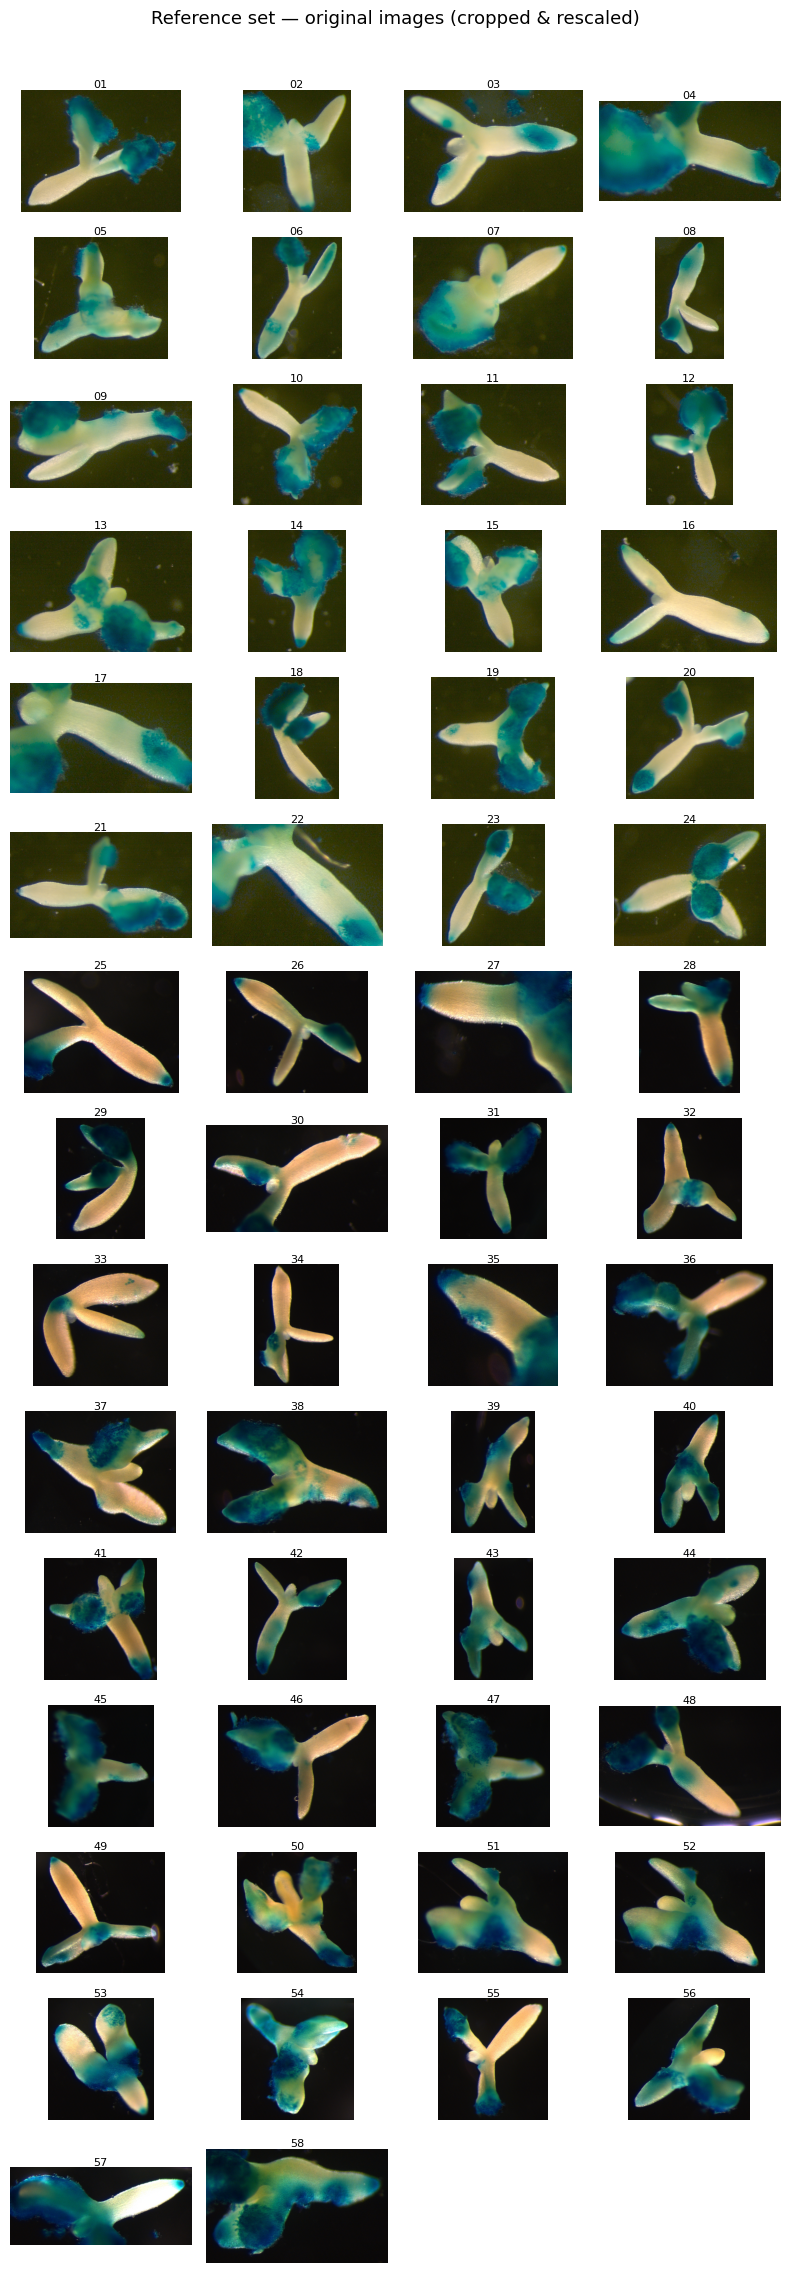

In [4]:
def show_panel(images, labels, nrows=15, ncols=4, binary=False, suptitle=None):
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.0, nrows * 1.5))
    for k, ax in enumerate(axes.ravel()):
        ax.axis("off")
        if k < len(images):
            ax.imshow(images[k], cmap="gray" if binary else None)
            ax.set_title(labels[k], fontsize=8, pad=1)
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

fig = show_panel(panel_orig, EMBRYO_IDS,
                 suptitle="Reference set — original images (cropped & rescaled)")
plt.show()

## 3. Panel of the binary masks  - method works for black background but not for green 



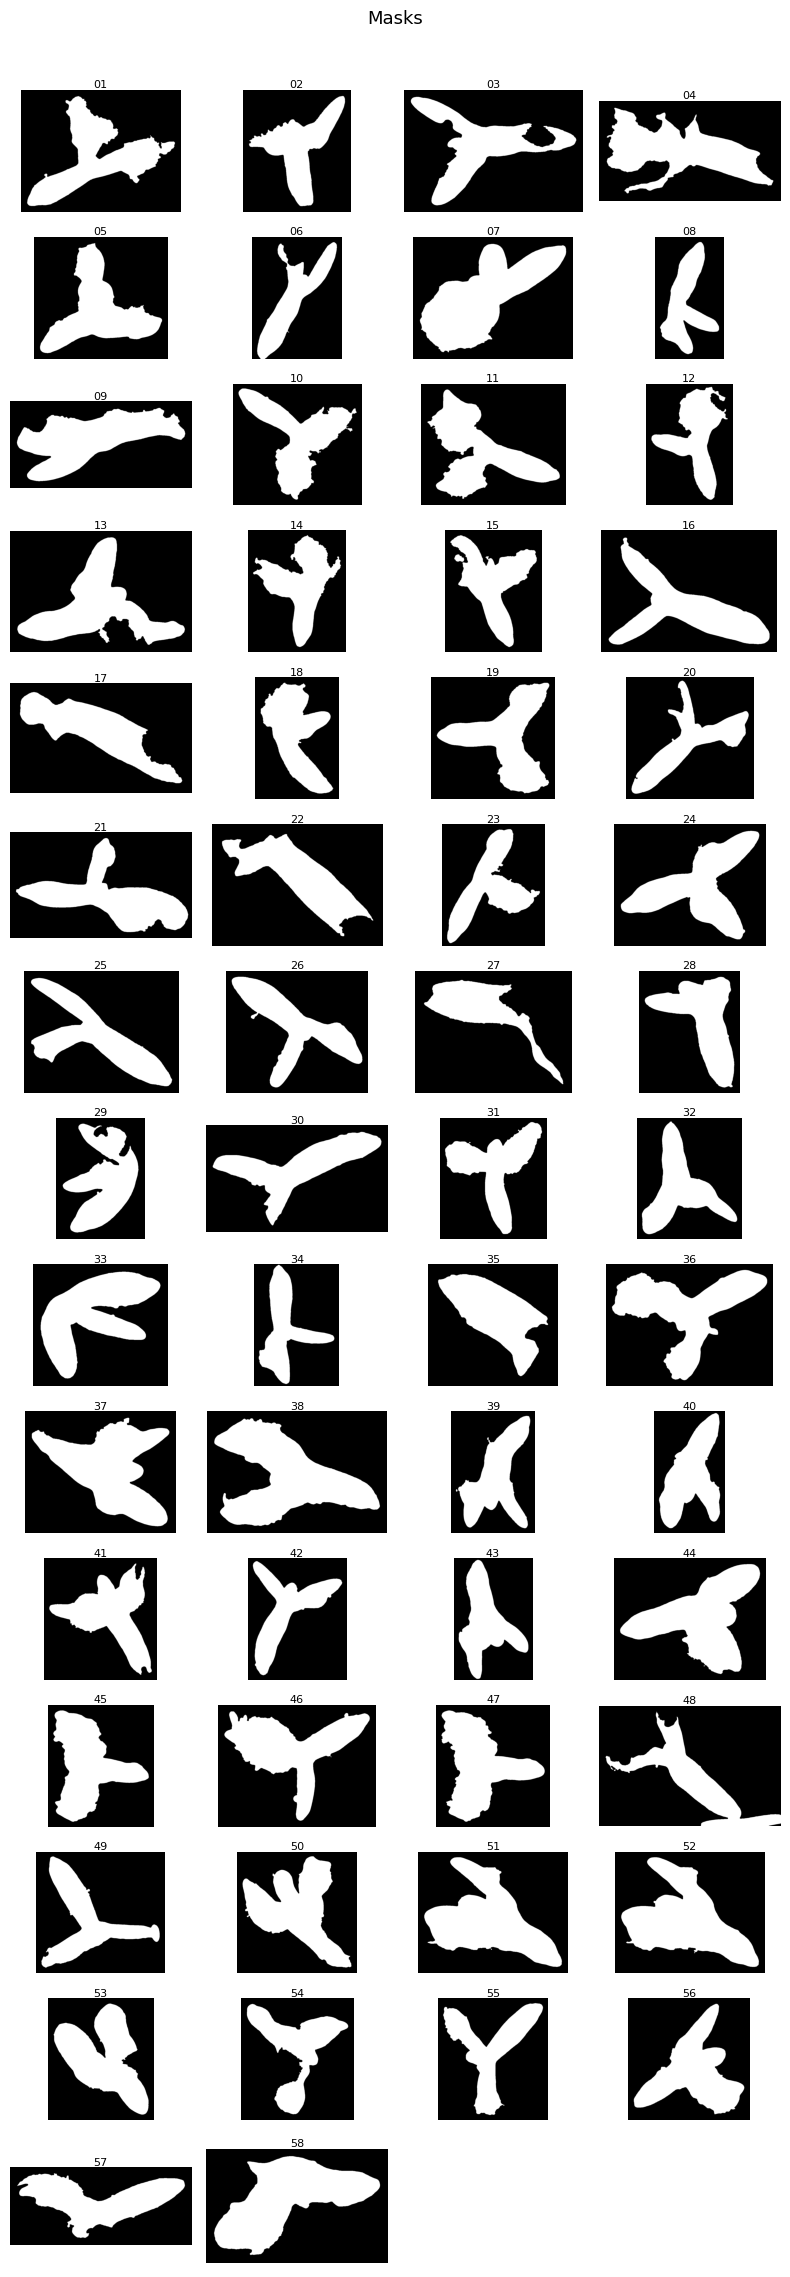

In [5]:
fig = show_panel(panel_mask, EMBRYO_IDS, binary=True,
                 suptitle="Masks")
plt.show()

---
# Part 2 — Shape, size and gene-expression measurements



## 2.1 — Size and shape features


In [32]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def blue_mask(rgb, mask, frac=0.40, erode=6, min_speck=150):
    """Boolean mask of blue (gene-expression) pixels inside the embryo.
    f_B = B/(R+G+B) > frac then pixel is blue."""
    rgb = rgb.astype(np.float64)  # 16-bit to  float. If we don't do this, the division will be wrong and frac_blue will be zero everywhere.
    interior = np.asarray(dip.BinaryErosion(dip.Image(mask), 1, erode)).astype(bool)
    R, G, B  = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    frac_blue = B / (R + G + B + 1e-6)  #  avoid division by zero
    bm = (frac_blue > frac) & interior
    bm = np.asarray(dip.AreaOpening(dip.Image(bm), filterSize=min_speck)).astype(bool)
    return bm


def measure_shape(mask):
    """Size + shape of a single-object boolean mask"""
    lab = dip.Label(dip.Image(mask))
    m = dip.MeasurementTool.Measure(
              lab, None, ["Size", "Perimeter", "Roundness", "Solidity"])
    
    g = lambda k: float(m[1][k][0])
    return dict(area=g("Size"), perimeter=g("Perimeter"), roundness=g("Roundness"),
                solidity=g("Solidity"))

In [34]:
masks, blue_masks, records = {}, {}, []
for eid in EMBRYO_IDS:
    rgb  = load_rgb(eid)
    mask = segment_embryo(rgb)
    bm   = blue_mask(rgb, mask)
    masks[eid], blue_masks[eid] = mask, bm
    sh = measure_shape(mask)
    blue_abs = int(bm.sum())
    records.append({"id": eid, **sh, "blue_abs": blue_abs,
                    "blue_rel": blue_abs / sh["area"]})

features = pd.DataFrame(records).set_index("id")
show = features.copy()
show["area"]      = show["area"].astype(int)
show["perimeter"] = show["perimeter"].round(0).astype(int)
show[["roundness", "solidity", "blue_rel"]] = \
        show[["roundness", "solidity", "blue_rel"]].round(3)
show

,area,perimeter,roundness,solidity,blue_abs,blue_rel
id,,,,,,
01,225251,3700,0.207,0.575,83229,0.369
02,157846,2468,0.326,0.659,7691,0.049
03,168853,3431,0.180,0.502,3515,0.021
04,166085,3323,0.189,0.603,64919,0.391
05,219523,2788,0.355,0.649,24186,0.110
06,168892,2942,0.245,0.584,13320,0.079
07,244691,2618,0.448,0.792,65149,0.266
08,170001,2629,0.309,0.650,29808,0.175
09,199484,2732,0.336,0.735,32632,0.164


Viusualisation

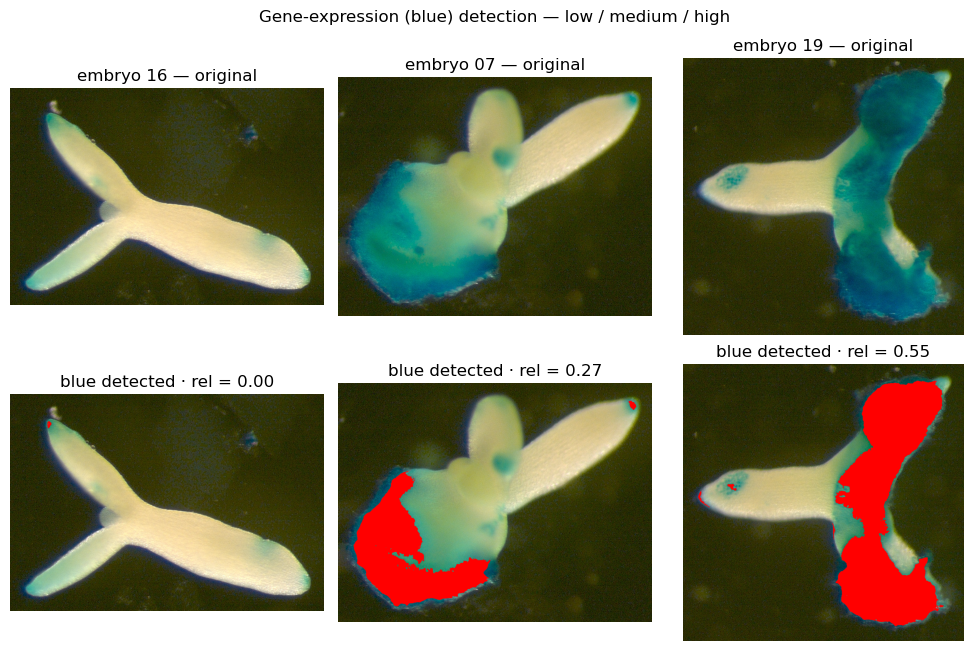

In [8]:
def overlay_blue(eid, colour=(255, 0, 0)):
    rgb  = load_rgb(eid)
    disp = to_uint8(rgb).copy()
    disp[blue_masks[eid]] = colour                       
    return crop_to_mask(disp, masks[eid]), crop_to_mask(to_uint8(rgb), masks[eid])

clean    = features[features.area > 120000].sort_values("blue_rel")   # representative
examples = [clean.index[0], clean.index[len(clean)//2], clean.index[-1]]

fig, ax = plt.subplots(2, 3, figsize=(10, 6.6))
for j, eid in enumerate(examples):
    over, orig = overlay_blue(eid)
    ax[0, j].imshow(orig); ax[0, j].axis("off"); ax[0, j].set_title(f"embryo {eid} — original")
    ax[1, j].imshow(over); ax[1, j].axis("off")
    ax[1, j].set_title(f"blue detected · rel = {features.loc[eid, 'blue_rel']:.2f}")
fig.suptitle("Gene-expression (blue) detection — low / medium / high", fontsize=12)
plt.tight_layout(); plt.show()